# Plot extra test results for Ath snRNA data

In [1]:
import os
import anndata
import scanpy as sc
import h5py
import polars as pl

In [2]:
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

In [3]:
# path_h5 = "/mnt/hdd2/homext/wuch/xn2p/run/predict/deeptan/snrna_full_extra/preds+seed_42+multitask_diffpool+tst.h5"
path_true = "/mnt/hdd2/homext/wuch/xn2p/data/raw_df/snRNA/ath_snrna_balanced_flower_seedling_rosette_split_full_extra/split_42_2.parquet"

In [8]:
pred_labels = pl.read_parquet("predicted_labels_of_extra_test.parquet")
pred_labels_list = pred_labels["multitask_diffpool"].to_list()

true_labels = pl.read_parquet("true_labels_of_extra_test.parquet")
true_labels_list = true_labels["multitask_diffpool"].to_list()

X_tst = pl.read_parquet(path_true)

In [9]:
# print(pred_labels)
# print(X_tst)

In [5]:
adata = anndata.AnnData(
    X=X_tst.drop("obs_names").to_numpy(),
    obs={'CellType': pred_labels_list},
)

/home/wuch/miniforge3/envs/pt28/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/wuch/miniforge3/envs/pt28/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_2229924/2524171355.py:11: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.8)


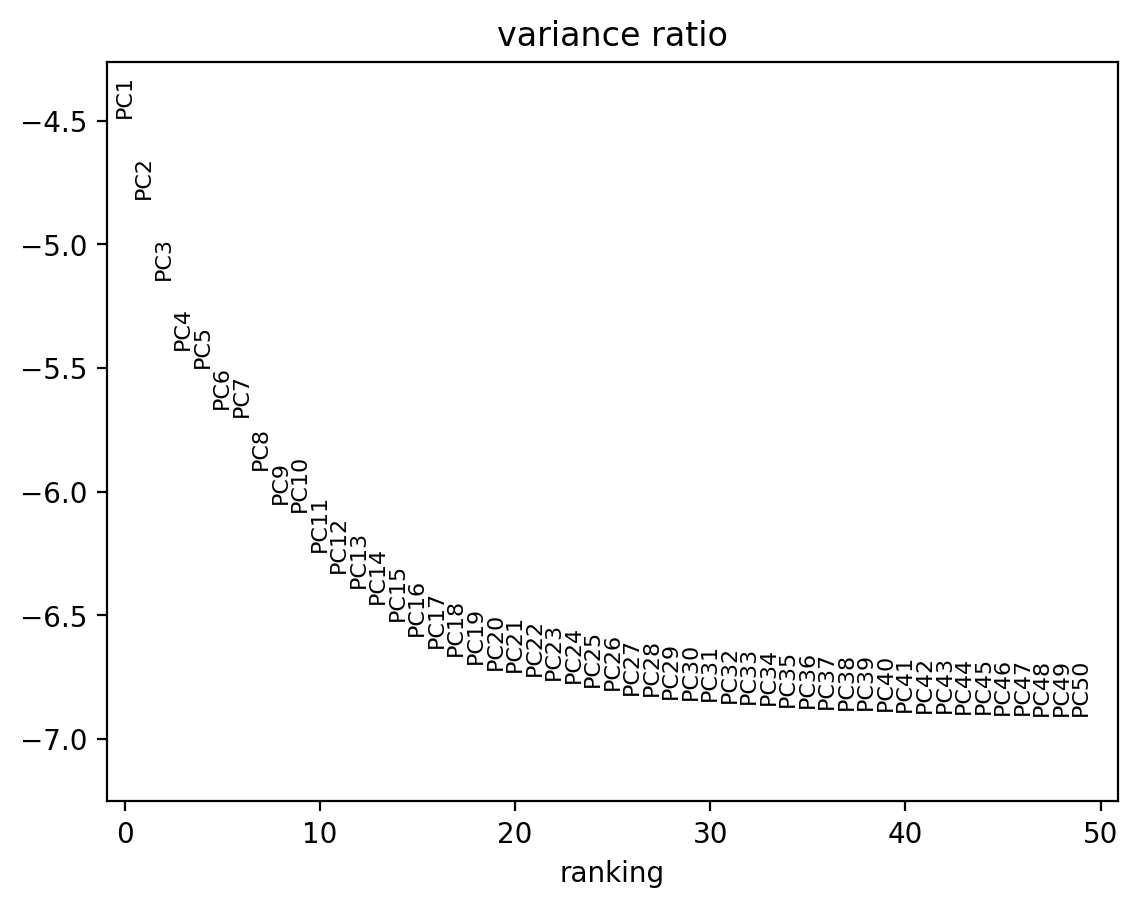

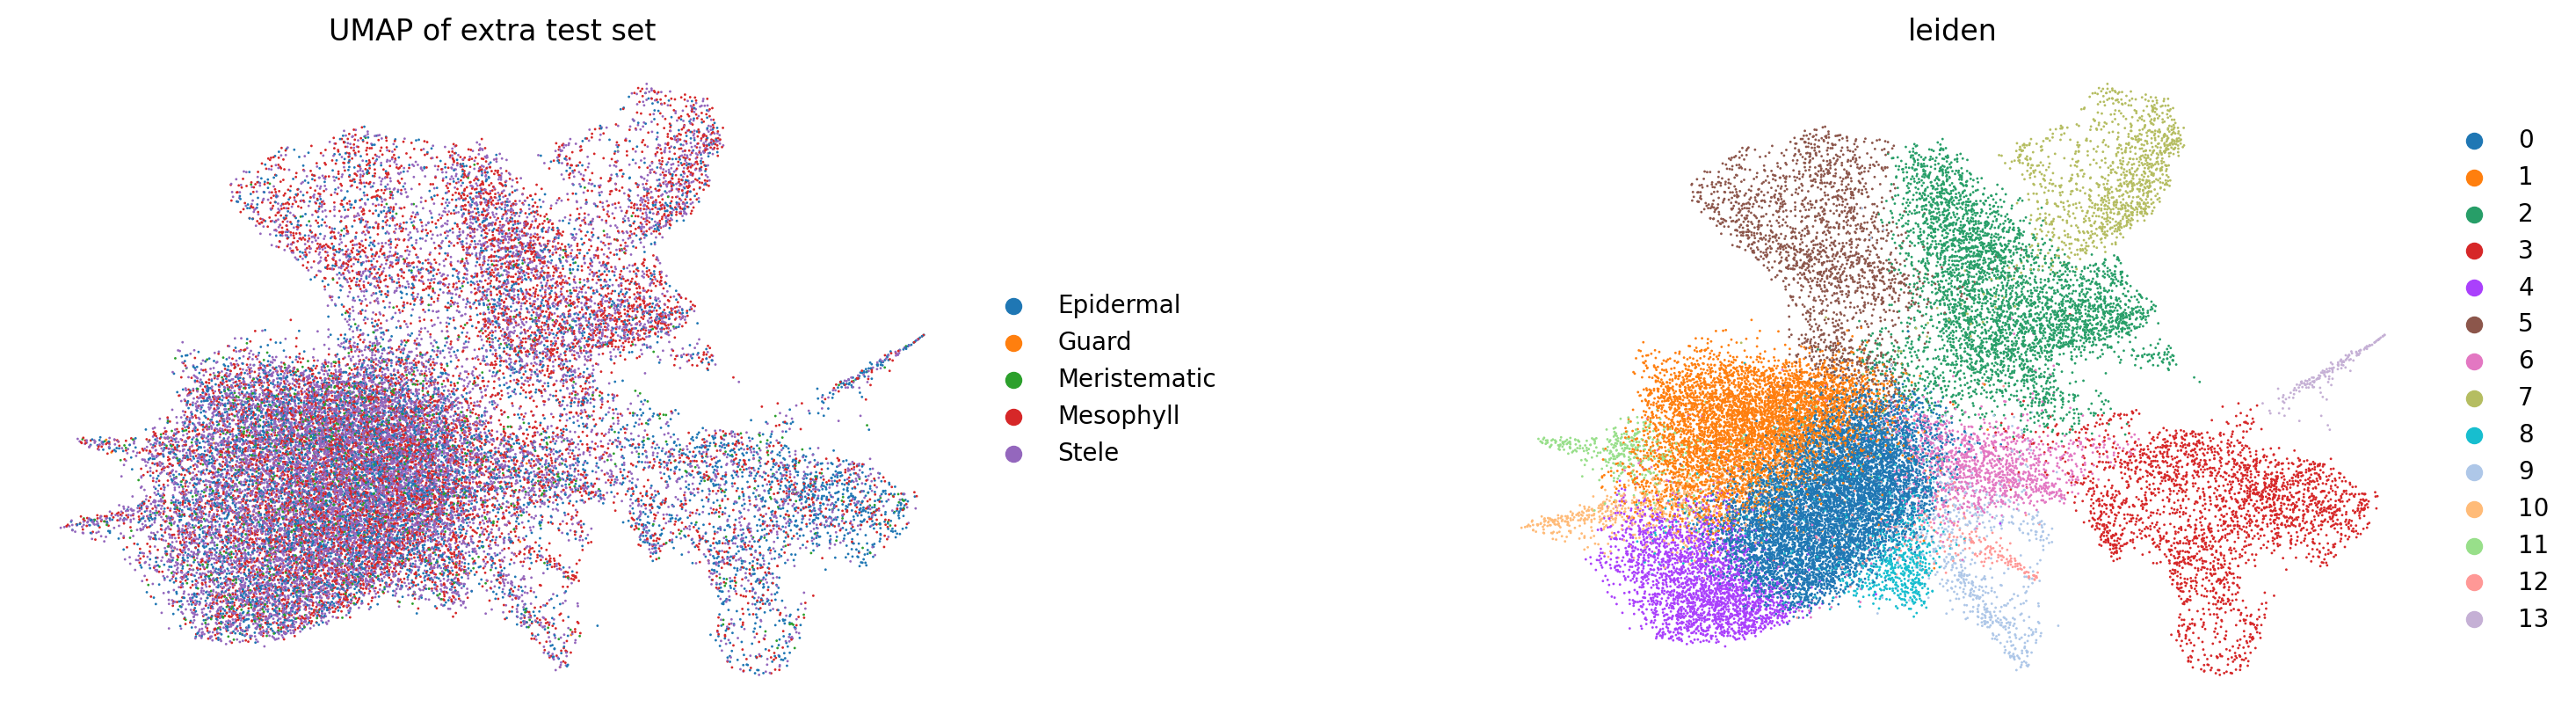

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=50)
sc.tl.leiden(adata, resolution=0.8)
sc.tl.umap(adata, min_dist=0.5, random_state=41)

sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pl.umap(adata, color=["CellType", "leiden"], wspace=0.4, title="UMAP of extra test set", frameon=False)

In [10]:
adata_true = anndata.AnnData(
    X=X_tst.drop("obs_names").to_numpy(),
    obs={'CellType': true_labels_list},
)

/home/wuch/miniforge3/envs/pt28/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


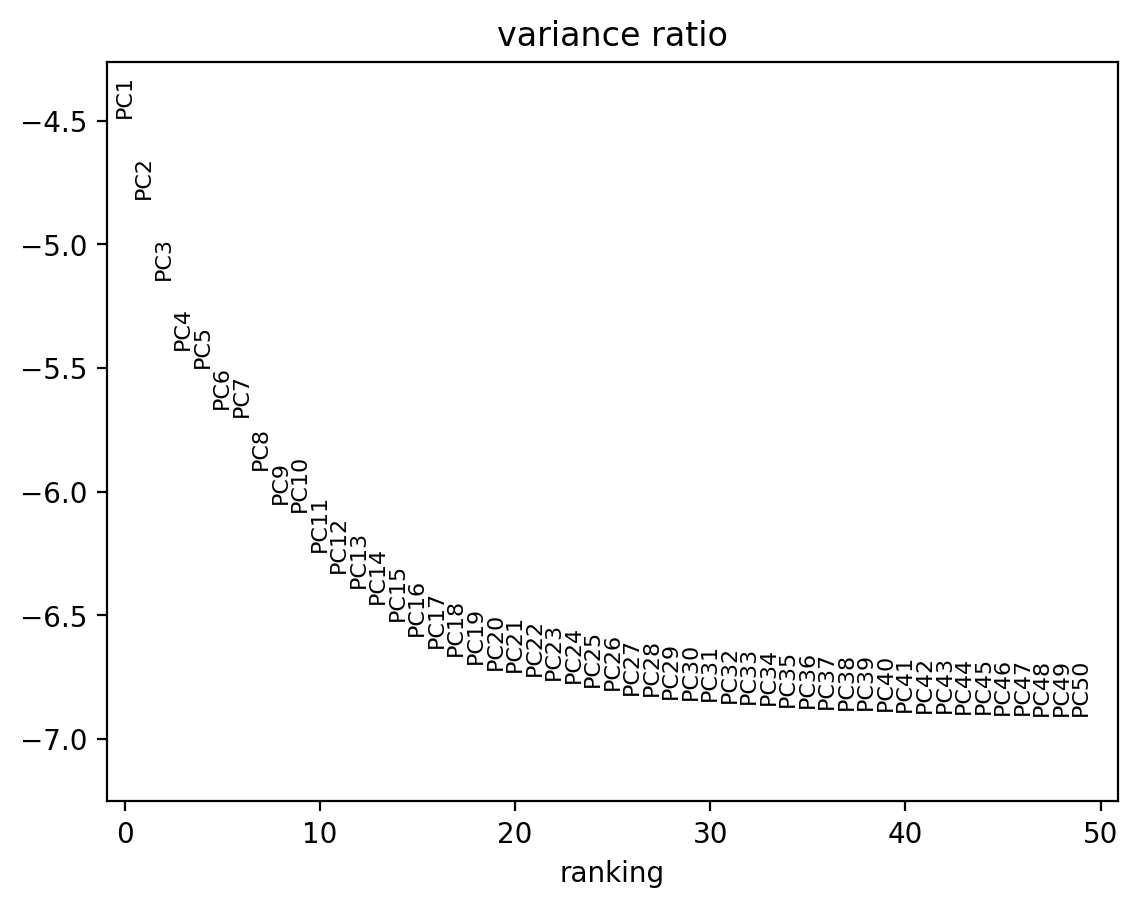

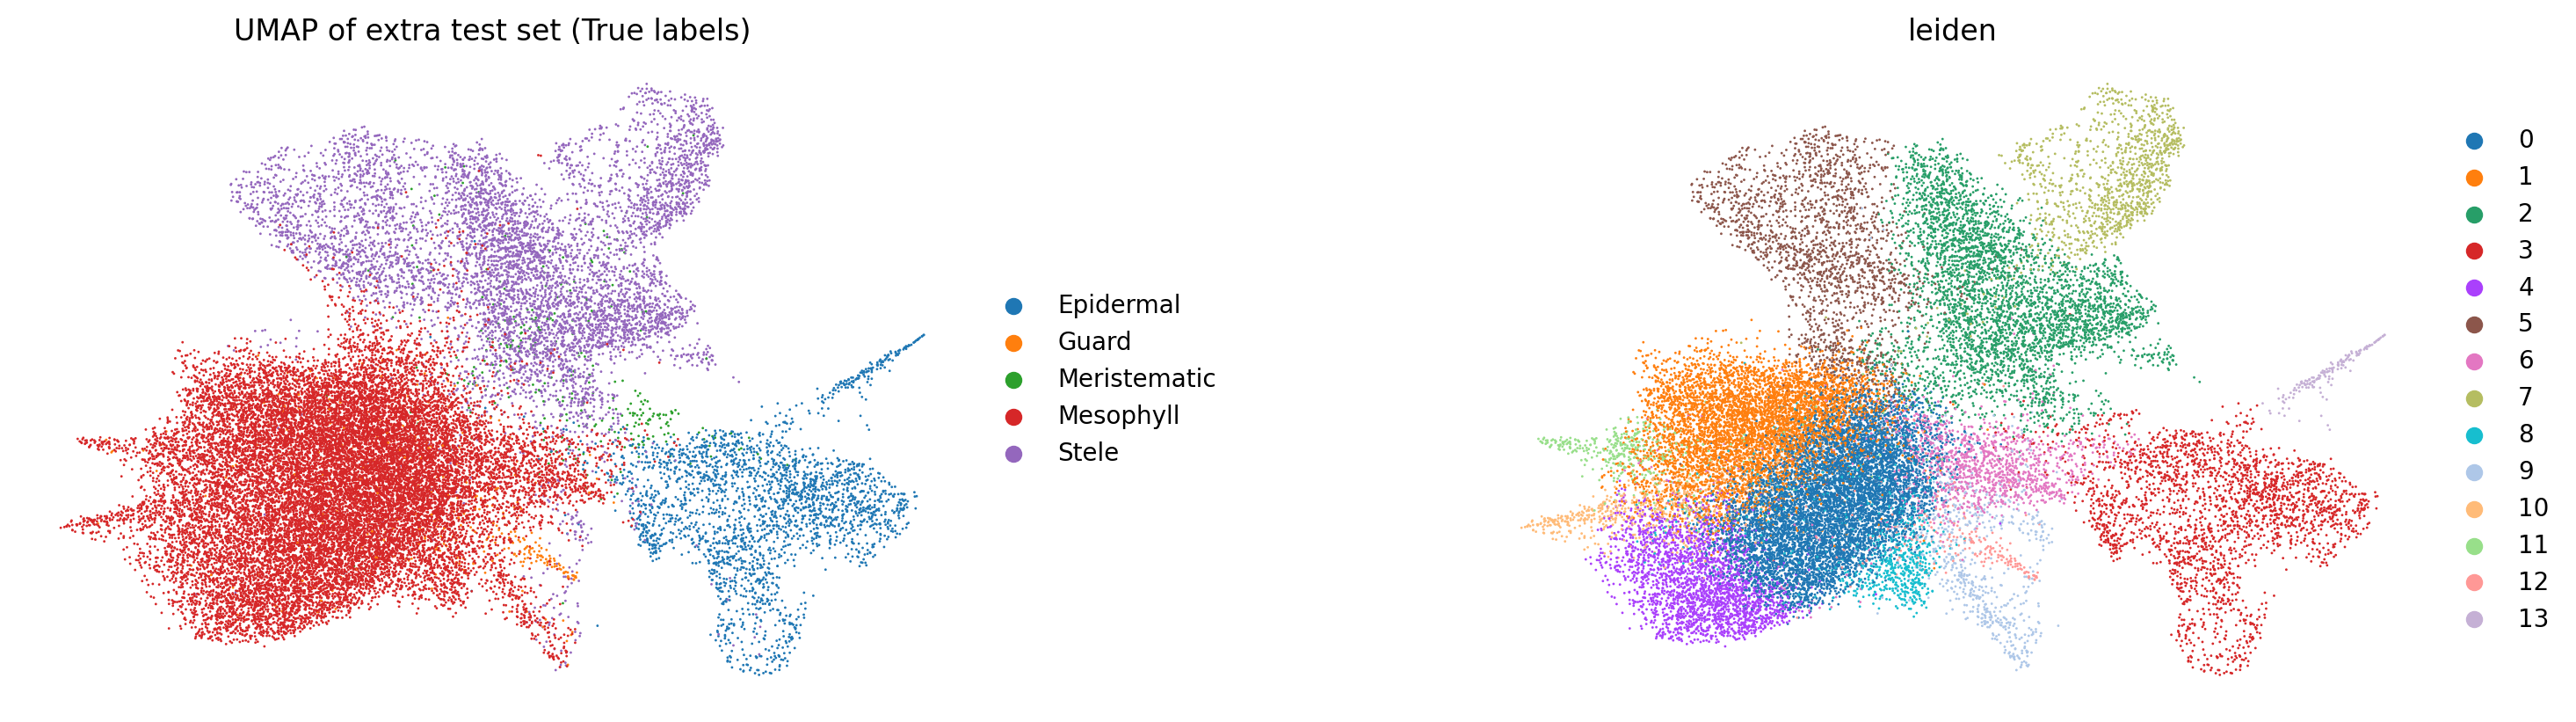

In [11]:
sc.pp.normalize_total(adata_true, target_sum=1e4)
sc.pp.log1p(adata_true)
sc.pp.highly_variable_genes(adata_true, n_top_genes=2000)
adata_true = adata_true[:, adata_true.var.highly_variable]
sc.pp.scale(adata_true, max_value=10)

sc.tl.pca(adata_true, n_comps=50)
sc.pp.neighbors(adata_true, n_neighbors=20, n_pcs=50)
sc.tl.leiden(adata_true, resolution=0.8)
sc.tl.umap(adata_true, min_dist=0.5, random_state=41)

sc.pl.pca_variance_ratio(adata_true, n_pcs=50, log=True)
sc.pl.umap(adata_true, color=["CellType", "leiden"], wspace=0.4, title="UMAP of extra test set (True labels)", frameon=False)